In [ ]:
!pip install psutil codecarbon

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
print("Obteniendo el dataset de MNIST de openml..")
# Fetching the dataset as numpy arrays
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# The data is flattened (784 pixels), so we reshape it back to 28x28 images
images = mnist.data.reshape(-1, 28, 28)
labels = mnist.target

images_test = images[60000:70000]
labels_test = labels[60000:70000]

print(f"Successfully loaded {images.shape[0]} images of size 28x28")
print(f"The test datasets are length {len(images_test)} and labels {len(labels_test)}")

Fetching MNIST dataset from OpenML...
Successfully loaded 70000 images of size 28x28
The test datasets are length 10000 and labels 10000


In [ ]:
def pad_image(image, final_size=256):
    """Embeds an image in the center of a zero-padded array to a 256x256 array"""
    h, w = image.shape
    pad_h = (final_size - h) // 2
    pad_w = (final_size - w) // 2
    # Pad evenly on all sides
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    return padded

def normalize(array):
    """Normalizes an array to be strictly between 0 and 1. That is, the intensities range in that interval"""
    return (array - np.min(array)) / (np.max(array) - np.min(array))

In [ ]:
def create_circular_mask(h, w, r_in=2, r_out=35, mask_type='bandpass'):
    """Creates the circular mask of 1 and 0's in order to represent the iris added in the frequency domain"""
    center = (int(w/2), int(h/2))
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    if mask_type == 'bandpass':
        # Blocks DC (inner) and High-Freq noise (outer)
        mask = (dist >= r_in) & (dist <= r_out)
    elif mask_type == 'highpass':
        mask = dist >= r_in
    elif mask_type == 'lowpass':
        mask = dist <= r_out
    else:
        mask = np.ones((h, w))
    return mask.astype(float)

def optical_correlator(input_img, target_img, apply_iris=True, r_in=2, r_out=35, mask_type='bandpass'):
    # Ensure float precision
    input_img = np.asarray(input_img, dtype=float)
    target_img = np.asarray(target_img, dtype=float)

    # LENS 1: Fourier Plane
    U_in_focal = np.fft.fftshift(np.fft.fft2(input_img))
    target_spectrum = np.fft.fftshift(np.fft.fft2(target_img))

    # CMF Filter or Reference Image
    H_filter = np.conj(target_spectrum)

    # Apply the circular iris
    if apply_iris:
        h, w = U_in_focal.shape
        # We pass r_in and r_out to the mask function
        iris_mask = create_circular_mask(h, w, r_in=r_in, r_out=r_out, mask_type=mask_type)
        H_filter = H_filter * iris_mask

    # LENS 2: Inverse Transform
    U_filtered = U_in_focal * H_filter
    U_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))

    return np.abs(U_out)**2

Exploring the dataset, testing the padding, the correct application of the FFT and the retrieval of the image

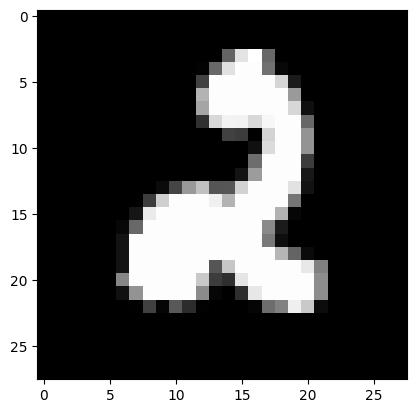

In [ ]:
plt.imshow(images[1391], cmap='gray')

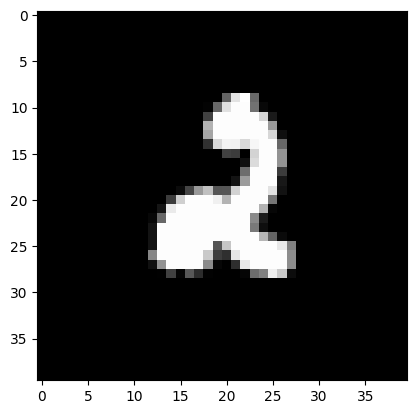

In [ ]:
test_img_preview = pad_image(images[1391])[108:148, 108:148]
plt.imshow(test_img_preview, cmap='gray')


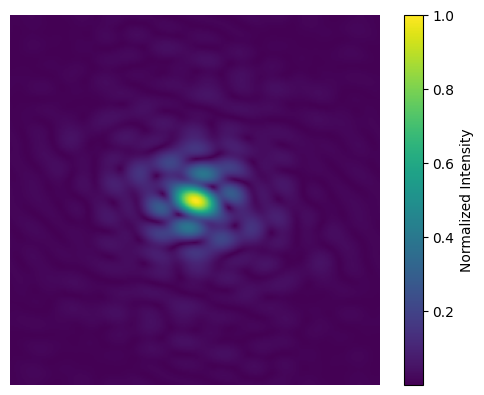

In [ ]:
test_img_preview = pad_image(images[1391])
ft_test_img_preview = np.fft.fftshift(np.fft.fft2(test_img_preview))

max_intensity = np.max(np.abs(ft_test_img_preview))

plt.imshow(np.abs(ft_test_img_preview)/max_intensity)
plt.axis('off')
cbar = plt.colorbar()
cbar.set_label('Normalized Intensity')

Adding a $r_{in}$ = 5 outer filter

In [ ]:
r = 5

h, w   = test_img_preview.shape
Y, X   = np.ogrid[:h, :w]
cx, cy = h//2, w//2

dist_sq = (X-cx)**2 + (Y-cy)**2

mask = dist_sq >= r**2

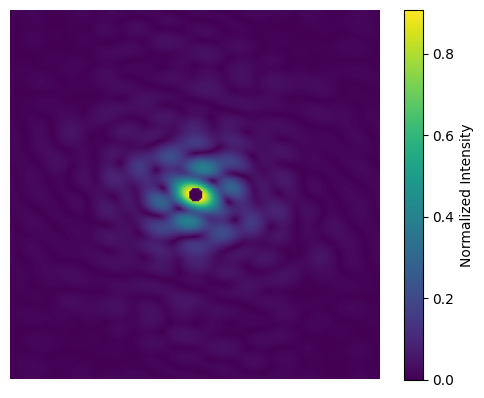

In [ ]:
plt.imshow(np.abs(mask*ft_test_img_preview)/max_intensity, cmap="viridis")

plt.axis('off')

cbar = plt.colorbar()
cbar.set_label('Normalized Intensity')



In [ ]:
ft_img_with_filter = mask * ft_test_img_preview

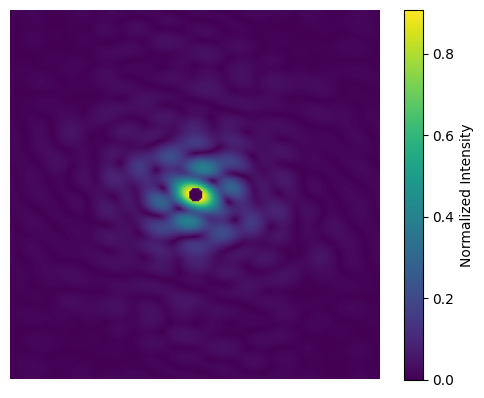

In [ ]:
plt.imshow(np.abs(ft_img_with_filter*mask)/max_intensity, cmap="viridis")
plt.axis('off')

cbar = plt.colorbar()
cbar.set_label('Normalized Intensity')

In [ ]:
recovered_image = np.fft.ifft2(np.fft.ifftshift(ft_img_with_filter))[108:148, 108:148]

(np.float64(-0.5), np.float64(39.5), np.float64(39.5), np.float64(-0.5))

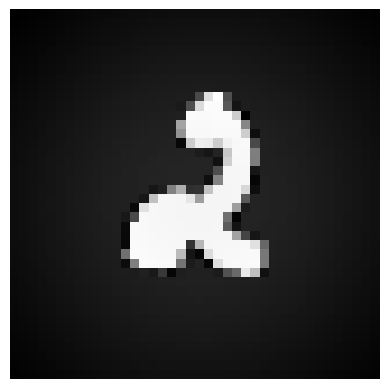

In [ ]:
plt.imshow(np.abs(recovered_image), cmap="gray")
plt.axis('off')

In [ ]:
# =====================================================================
# Ensuring a 1D integers array
# =====================================================================

labels_test_clean = np.asarray(labels_test, dtype=int).flatten()

indices_prueba = []
etiquetas_seleccionadas = []

# Change these to scale easily. Use just 100 images to test
images_per_class = 100
total_classes = 10

# =====================================================================
# Seed for reproducibility
# =====================================================================
SEMILLA_PRUEBA = 42
np.random.seed(SEMILLA_PRUEBA)

print(f"Iniciando selección estructurada de {images_per_class} imágenes por clase")

#  Selecting 100 images per class
for i in range(total_classes):
    # Searching the indexes using our clean array
    idx_clase = np.where(labels_test_clean == i)[0]

    # Increasing the size to 100
    if len(idx_clase) >= images_per_class:
        seleccion = np.random.choice(idx_clase, size=images_per_class, replace=False)
    else:
        print(f"ADVERTENCIA: La clase {i} solo tiene {len(idx_clase)} imágenes. Usando todas.")
        seleccion = idx_clase

    indices_prueba.extend(seleccion)
    etiquetas_seleccionadas.extend([i] * len(seleccion))

# Turning into numpy arrays
indices_prueba = np.array(indices_prueba)
etiquetas_seleccionadas = np.array(etiquetas_seleccionadas)

# Strict verification
print("\nVerificando la distribución de clases")
clases_unicas, conteos = np.unique(etiquetas_seleccionadas, return_counts=True)

verificacion_exitosa = True
for clase, conteo in zip(clases_unicas, conteos):
    print(f"Clase {clase}: {conteo} imágenes seleccionadas.")
    if conteo != images_per_class:
        verificacion_exitosa = False

# Index saving
# Testing that the results are what we expect
expected_total = images_per_class * total_classes

if verificacion_exitosa and len(indices_prueba) == expected_total:
    print(f"\n¡Verificación exitosa! Hay exactamente {images_per_class} imágenes por cada clase.")

    # Save the index array in a binary numpy file
    filename = f'indices_muestra_{expected_total}.npy'
    np.save(filename, indices_prueba)
    print(f"Índices guardados correctamente en '{filename}'.")
else:
    print(f"\nERROR: La distribución no es correcta (Total: {len(indices_prueba)}/{expected_total}). Revisa el dataset de origen.")

Iniciando selección estructurada de 100 imágenes por clase...

Verificando la distribución de clases...
Clase 0: 100 imágenes seleccionadas.
Clase 1: 100 imágenes seleccionadas.
Clase 2: 100 imágenes seleccionadas.
Clase 3: 100 imágenes seleccionadas.
Clase 4: 100 imágenes seleccionadas.
Clase 5: 100 imágenes seleccionadas.
Clase 6: 100 imágenes seleccionadas.
Clase 7: 100 imágenes seleccionadas.
Clase 8: 100 imágenes seleccionadas.
Clase 9: 100 imágenes seleccionadas.

¡Verificación exitosa! Hay exactamente 100 imágenes por cada clase.
Índices guardados correctamente en 'indices_muestra_1000.npy'.


Generando filtros promediados para mejorar robustez...
Cargando índices de prueba estructurados...
Iniciando clasificación de 1000 imágenes (10 por clase)...
Iniciando clasificación de 1000 imágenes (256x256)...

   MÉTRICAS DE CLASIFICACIÓN (1 TUPLA)
Precisión global (Accuracy): 0.7200

Reporte detallado (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       100
           1       0.56      0.88      0.69        99
           2       0.90      0.72      0.80       102
           3       0.68      0.78      0.73       101
           4       0.72      0.79      0.76       107
           5       0.76      0.55      0.64        77
           6       0.82      0.80      0.81       104
           7       0.77      0.65      0.70       114
           8       0.65      0.47      0.55        96
           9       0.61      0.56      0.58       100

    accuracy                           0.72      1000
   macro avg

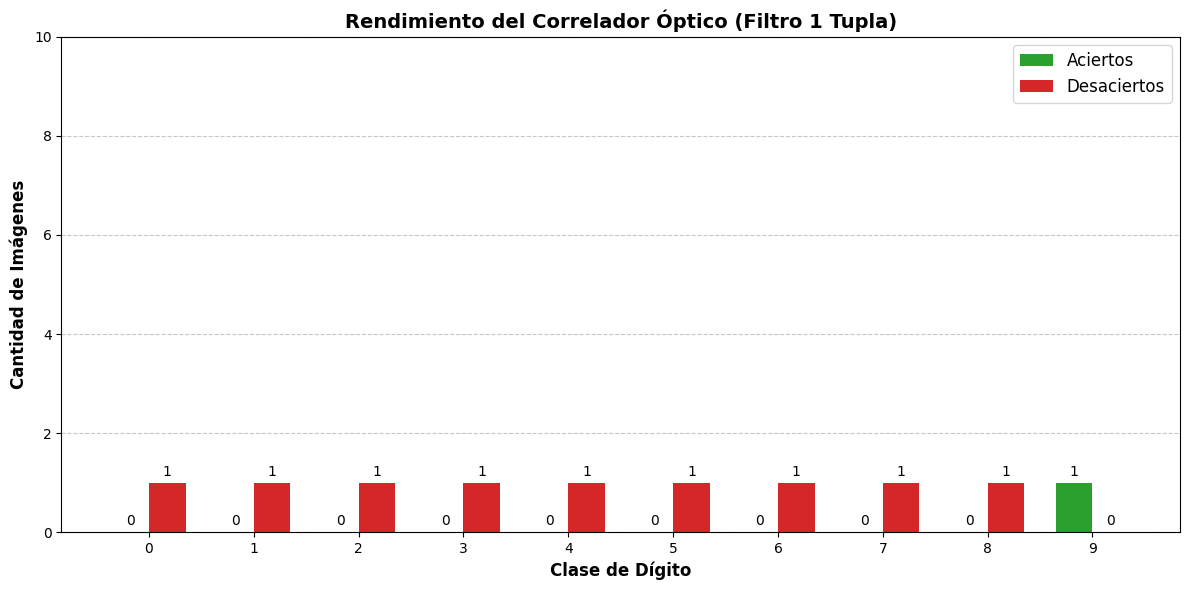

In [ ]:
# ==========================================
# Generating average filters
# ==========================================
reference_images = {}
print("Generando filtros promediados para mejorar robustez...")

for i in range(10):
    # Taking the first 20 tuples of each digit to average them and
    idxs = np.where(labels == str(i))[0][:20]

    # Promediamos las imágenes para obtener la "forma esencial" del número
    avg_template = np.mean([pad_image(images[idx]) for idx in idxs], axis=0)

    # Normalizamos la energía del filtro promedio
    total_energy = np.sqrt(np.sum(avg_template**2))
    reference_images[i] = avg_template / (total_energy + 1e-12)

# ==========================================
# 2. CARGA DE DATOS ESTRUCTURADOS
# ==========================================
print("Cargando índices de prueba estructurados...")
try:
    # Cargamos los índices previamente guardados para asegurar reproducibilidad
    indices_prueba = np.load('indices_muestra_1000.npy')
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró 'indices_muestra_100.npy'. Ejecuta primero el script de selección.")

y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (10 por clase)...")

# ==========================================
# 3. BUCLE DE CLASIFICACIÓN ÓPTICA (DEBUGGED)
# ==========================================
y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (256x256)...")

for count, idx in enumerate(indices_prueba):
    test_img = pad_image(images[idx])
    true_label = int(labels[idx])

    # Normalización de energía (L2) - Vital para que el '8' no gane por brillo
    test_energy = np.sqrt(np.sum(test_img**2))
    if test_energy > 0:
        test_img = test_img / test_energy

    peak_intensities = np.zeros(10)

    for i in range(10):
        # FIX: Changed 'iris_radius' to 'r_in' and 'r_out'
        # For 256x256, r_in=2 blocks the DC, r_out=35 captures the 28x28 digit.
        I_out = optical_correlator(
            test_img,
            reference_images[i],
            apply_iris=True,
            r_in=4,
            r_out=35,
            mask_type='bandpass'
        )
        peak_intensities[i] = np.max(I_out)

    # El ganador es el índice con el pico de intensidad pura más alto
    predicted_digit = np.argmax(peak_intensities)

    y_true.append(true_label)
    y_pred.append(predicted_digit)
# ==========================================
# 4. CÁLCULO DE MÉTRICAS ESTÁNDAR
# ==========================================
print("\n" + "="*45)
print("   MÉTRICAS DE CLASIFICACIÓN (1 TUPLA)")
print("="*45)
print(f"Precisión global (Accuracy): {accuracy_score(y_true, y_pred):.4f}\n")

print("Reporte detallado (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred))

print("Matriz de Confusión:")
print(confusion_matrix(y_true, y_pred))

# ==========================================
# 5. GENERACIÓN DE GRÁFICA DE RENDIMIENTO
# ==========================================
aciertos = np.zeros(10)
desaciertos = np.zeros(10)

for i in range(10):
    # Máscara para aislar las 10 imágenes reales del dígito 'i'
    mask = (y_true == i)
    aciertos[i] = np.sum(y_pred[mask] == i)
    desaciertos[i] = np.sum(y_pred[mask] != i)

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, aciertos, width, label='Aciertos', color='#2ca02c')
rects2 = ax.bar(x + width/2, desaciertos, width, label='Desaciertos', color='#d62728')

ax.set_xlabel('Clase de Dígito', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Imágenes', fontsize=12, fontweight='bold')
ax.set_title('Rendimiento del Correlador Óptico (Filtro 1 Tupla)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_yticks(np.arange(0, 12, 2))
ax.legend(fontsize=12)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

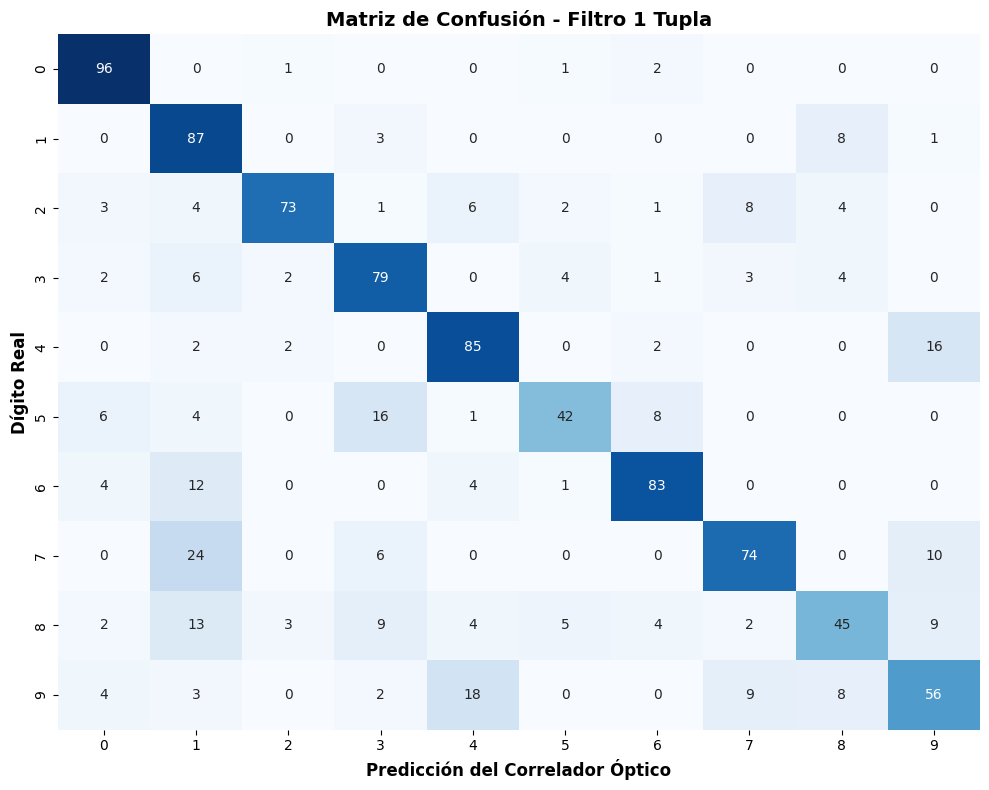

In [ ]:
import seaborn as sns

# Calculamos la matriz de confusión usando tus arreglos de la simulación
cm = confusion_matrix(y_true, y_pred)

# Configuramos la figura
plt.figure(figsize=(10, 8))

# Generamos el mapa de calor
# annot=True pone los números dentro de los cuadros, cmap='Blues' da un tono profesional
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicción del Correlador Óptico', fontsize=12, fontweight='bold')
plt.ylabel('Dígito Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Filtro 1 Tupla', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

<b> Filter constituted by an average of 50 images, highpass

Generando filtros promediados (N=1000) para mejorar robustez...
Cargando índices de prueba estructurados...
Iniciando clasificación de 1000 imágenes (10 por clase)...

   MÉTRICAS DE CLASIFICACIÓN (FILTRO PROMEDIADO)
Precisión global (Accuracy): 0.8050

Reporte detallado (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       100
           1       0.75      0.89      0.81        99
           2       0.96      0.70      0.81       102
           3       0.76      0.84      0.80       101
           4       0.88      0.83      0.86       107
           5       0.86      0.62      0.72        77
           6       0.86      0.91      0.89       104
           7       0.81      0.85      0.83       114
           8       0.69      0.64      0.66        96
           9       0.66      0.76      0.71       100

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.80    

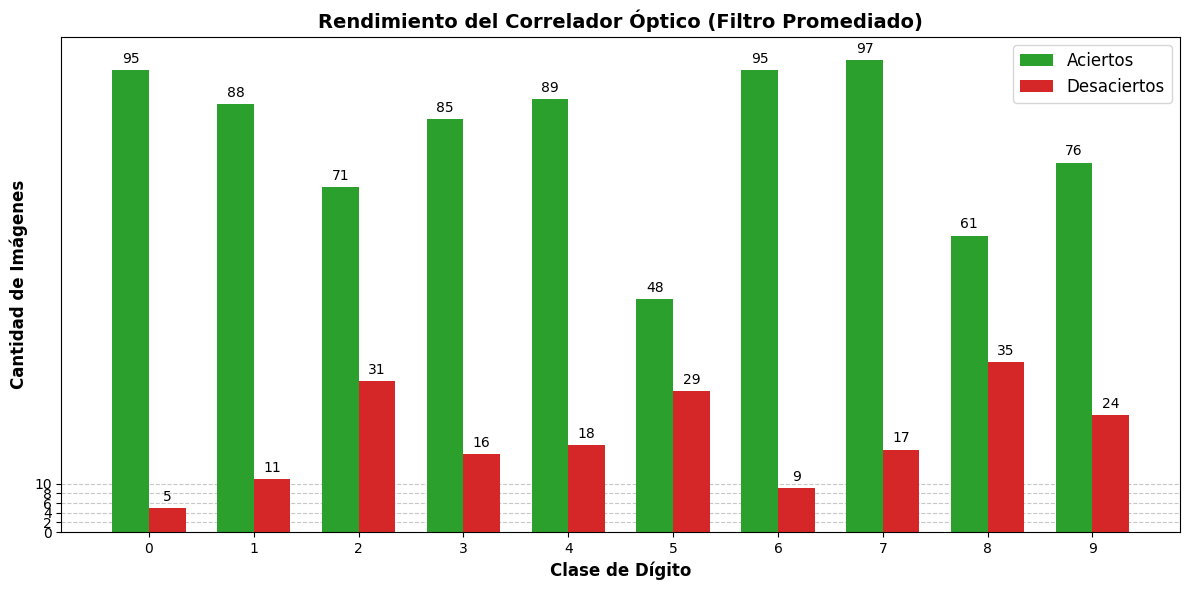

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 0. FUNCIONES SINCRONIZADAS DEL CORRELADOR
# ==========================================
def create_circular_mask(h, w, r_in=2, r_out=45, mask_type='bandpass'):
    center = (int(w/2), int(h/2))
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    if mask_type == 'bandpass':
        mask = (dist >= r_in) & (dist <= r_out)
    elif mask_type == 'highpass':
        mask = dist >= r_in
    elif mask_type == 'lowpass':
        mask = dist <= r_out
    else:
        mask = np.ones((h, w))
    return mask.astype(float)

def optical_correlator(input_img, target_img, apply_iris=True, r_in=2, r_out=45, mask_type='bandpass'):
    input_img = np.asarray(input_img, dtype=float)
    target_img = np.asarray(target_img, dtype=float)

    U_in_focal = np.fft.fftshift(np.fft.fft2(input_img))
    target_spectrum = np.fft.fftshift(np.fft.fft2(target_img))
    H_filter = np.conj(target_spectrum)

    if apply_iris:
        h, w = U_in_focal.shape
        iris_mask = create_circular_mask(h, w, r_in=r_in, r_out=r_out, mask_type=mask_type)
        H_filter = H_filter * iris_mask

    U_filtered = U_in_focal * H_filter
    U_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))
    return np.abs(U_out)**2

# ==========================================
# 1. GENERACIÓN DE FILTROS SINTÉTICOS (PROMEDIO)
# ==========================================
reference_images = {}
NUM_PROMEDIO = 1000  # Promediamos las primeras 50 imágenes para capturar la "esencia"
print(f"Generando filtros promediados (N={NUM_PROMEDIO}) para mejorar robustez...")

for i in range(10):
    # Tomamos las primeras 'N' apariciones de cada dígito
    idxs = np.where(labels == str(i))[0][:NUM_PROMEDIO]

    # Promediamos las imágenes en el espacio espacial
    avg_template = np.mean([pad_image(images[idx]) for idx in idxs], axis=0)

    # Normalizamos la energía del filtro promedio (Norma L2)
    total_energy = np.sqrt(np.sum(avg_template**2))
    reference_images[i] = avg_template / (total_energy + 1e-12)

# ==========================================
# 2. CARGA DE DATOS ESTRUCTURADOS
# ==========================================
print("Cargando índices de prueba estructurados...")
try:
    indices_prueba = np.load('indices_muestra_1000.npy')
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró 'indices_muestra_100.npy'.")

y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (10 por clase)...")

# ==========================================
# 3. BUCLE DE CLASIFICACIÓN ÓPTICA
# ==========================================
for count, idx in enumerate(indices_prueba):
    test_img = pad_image(images[idx])
    true_label = int(labels[idx])

    # Normalización L2 espacial (Imprescindible para equilibrar energías)
    test_energy = np.sqrt(np.sum(test_img**2))
    if test_energy > 0:
        test_img = test_img / test_energy

    peak_intensities = np.zeros(10)

    # Correlación contra los 10 filtros promediados
    for i in range(10):
        # Ajustado para el padding de 256x256: r_in=2 bloquea DC, r_out=45 mantiene forma
        I_out = optical_correlator(
            test_img,
            reference_images[i],
            apply_iris=True,
            r_in=2,
            r_out=35,
            mask_type='highpass'
        )
        peak_intensities[i] = np.max(I_out)

    # El ganador es el pico de correlación más brillante
    predicted_digit = np.argmax(peak_intensities)

    # Guardamos los resultados
    y_true.append(true_label)
    y_pred.append(predicted_digit)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ==========================================
# 4. CÁLCULO DE MÉTRICAS ESTÁNDAR
# ==========================================
print("\n" + "="*45)
print("   MÉTRICAS DE CLASIFICACIÓN (FILTRO PROMEDIADO)")
print("="*45)
print(f"Precisión global (Accuracy): {accuracy_score(y_true, y_pred):.4f}\n")

print("Reporte detallado (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred))

print("Matriz de Confusión:")
print(confusion_matrix(y_true, y_pred))

# ==========================================
# 5. GENERACIÓN DE GRÁFICA DE RENDIMIENTO
# ==========================================
aciertos = np.zeros(10)
desaciertos = np.zeros(10)

for i in range(10):
    mask = (y_true == i)
    aciertos[i] = np.sum(y_pred[mask] == i)
    desaciertos[i] = np.sum(y_pred[mask] != i)

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, aciertos, width, label='Aciertos', color='#2ca02c')
rects2 = ax.bar(x + width/2, desaciertos, width, label='Desaciertos', color='#d62728')

ax.set_xlabel('Clase de Dígito', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Imágenes', fontsize=12, fontweight='bold')
ax.set_title('Rendimiento del Correlador Óptico (Filtro Promediado)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_yticks(np.arange(0, 12, 2))
ax.legend(fontsize=12)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

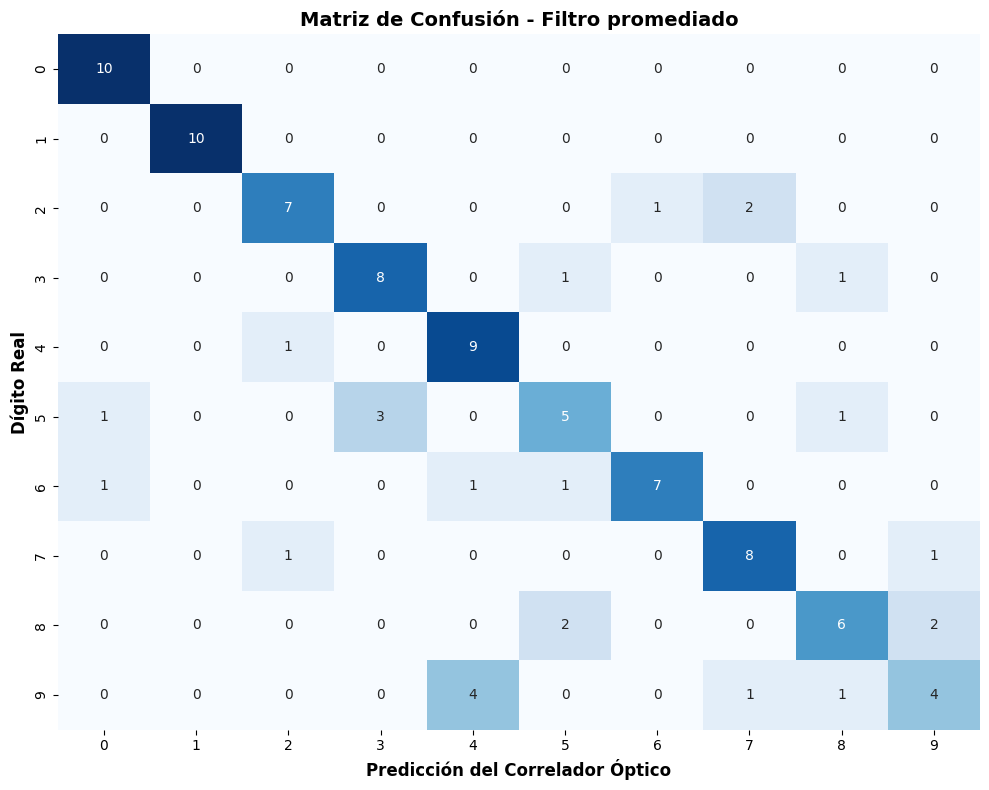

In [ ]:
import seaborn as sns

# Calculamos la matriz de confusión usando tus arreglos de la simulación
cm = confusion_matrix(y_true, y_pred)

# Configuramos la figura
plt.figure(figsize=(10, 8))

# Generamos el mapa de calor
# annot=True pone los números dentro de los cuadros, cmap='Blues' da un tono profesional
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicción del Correlador Óptico', fontsize=12, fontweight='bold')
plt.ylabel('Dígito Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Filtro promediado', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

<b> Modyfing a little bit the way that the sample digits to test our correlators are working, more test images.

In [ ]:
import numpy as np

indices_prueba = []
etiquetas_seleccionadas = []

# CONFIGURATION: Change these to scale easily
images_per_class = 100
total_classes = 10

print(f"Iniciando selección estructurada de {images_per_class} imágenes por clase...")

# 1. Selección de 100 imágenes por clase
for i in range(total_classes):
    # Encontramos todos los índices correspondientes al dígito 'i'
    idx_clase = np.where(labels == str(i))[0]

    # SELECCIÓN: Aumentamos el tamaño a 100
    if len(idx_clase) >= images_per_class:
        seleccion = np.random.choice(idx_clase, size=images_per_class, replace=False)
    else:
        print(f"ADVERTENCIA: La clase {i} solo tiene {len(idx_clase)} imágenes. Usando todas.")
        seleccion = idx_clase

    indices_prueba.extend(seleccion)
    etiquetas_seleccionadas.extend([i] * len(seleccion))

# Convertimos a arreglos de numpy
indices_prueba = np.array(indices_prueba)
etiquetas_seleccionadas = np.array(etiquetas_seleccionadas)

# 2. Verificación Estricta
print("\nVerificando la distribución de clases...")
clases_unicas, conteos = np.unique(etiquetas_seleccionadas, return_counts=True)

verificacion_exitosa = True
for clase, conteo in zip(clases_unicas, conteos):
    print(f"Dígito {clase}: {conteo} imágenes seleccionadas.")
    if conteo != images_per_class:
        verificacion_exitosa = False

# 3. Guardado de los índices
# Comprobamos que el total sea 1000 (10 clases * 100 imágenes)
expected_total = images_per_class * total_classes

if verificacion_exitosa and len(indices_prueba) == expected_total:
    print(f"\n¡Verificación exitosa! Hay exactamente {images_per_class} imágenes por cada clase.")

    # Guardamos el arreglo de índices en un archivo binario de numpy
    filename = f'indices_muestra_{expected_total}.npy'
    np.save(filename, indices_prueba)
    print(f"Índices guardados correctamente en '{filename}'.")
else:
    print(f"\nERROR: La distribución no es correcta (Total: {len(indices_prueba)}/{expected_total}). Revisa el dataset de origen.")

Iniciando selección estructurada de 100 imágenes por clase...

Verificando la distribución de clases...
Dígito 0: 100 imágenes seleccionadas.
Dígito 1: 100 imágenes seleccionadas.
Dígito 2: 100 imágenes seleccionadas.
Dígito 3: 100 imágenes seleccionadas.
Dígito 4: 100 imágenes seleccionadas.
Dígito 5: 100 imágenes seleccionadas.
Dígito 6: 100 imágenes seleccionadas.
Dígito 7: 100 imágenes seleccionadas.
Dígito 8: 100 imágenes seleccionadas.
Dígito 9: 100 imágenes seleccionadas.

¡Verificación exitosa! Hay exactamente 100 imágenes por cada clase.
Índices guardados correctamente en 'indices_muestra_1000.npy'.


# **Parte final con métricas**

[codecarbon WARNING @ 21:44:52] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 21:44:52] [setup] RAM Tracking...
[codecarbon INFO @ 21:44:52] [setup] CPU Tracking...


Generando filtros promediados (N=50) para mejorar robustez...


[codecarbon WARNING @ 21:44:53] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 21:44:53] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 21:44:53] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 21:44:53] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 21:44:53] [setup] GPU Tracking...
[codecarbon INFO @ 21:44:53] No GPU found.
[codecarbon INFO @ 21:44:53] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 21:44:53] >>> Tracker's metadata:
[codecarbon INFO @ 21:44:53]   Platf

Cargando índices de prueba estructurados...
Iniciando clasificación de 1000 imágenes...


[codecarbon INFO @ 21:44:54] Energy consumed for RAM : 0.000003 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:44:54] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 21:44:54] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 21:44:54] 0.000015 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:44:55] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:44:55] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 21:44:55] Energy consumed for All CPU : 0.000024 kWh
[codecarbon INFO @ 21:44:55] 0.000029 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:44:56] Energy consumed for RAM : 0.000008 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:44:56] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 21:44:56] Energy consumed for All CPU


   PERFIL DE RECURSOS (RESOURCE PROFILING)
FASE DE ENTRENAMIENTO (Generación de filtros):
  - Tiempo de ejecución : 0.2182 segundos
  - Consumo de RAM (Est): 0.00 MB
  - Energía consumida   : 0.000003 kWh

FASE DE EVALUACIÓN (Correlación):
  - Tiempo de ejecución : 71.4545 segundos
  - Consumo de RAM (Est): 0.31 MB
  - Energía consumida   : 0.001034 kWh

   MÉTRICAS DE CLASIFICACIÓN (FILTRO PROMEDIADO)
Precisión global (Accuracy): 0.7260

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       100
           1       0.68      0.87      0.76        99
           2       0.94      0.61      0.74       102
           3       0.70      0.80      0.75       101
           4       0.89      0.80      0.84       107
           5       0.68      0.51      0.58        77
           6       0.79      0.85      0.81       104
           7       0.68      0.69      0.68       114
           8       0.63      0.52      0.57        96
           9   

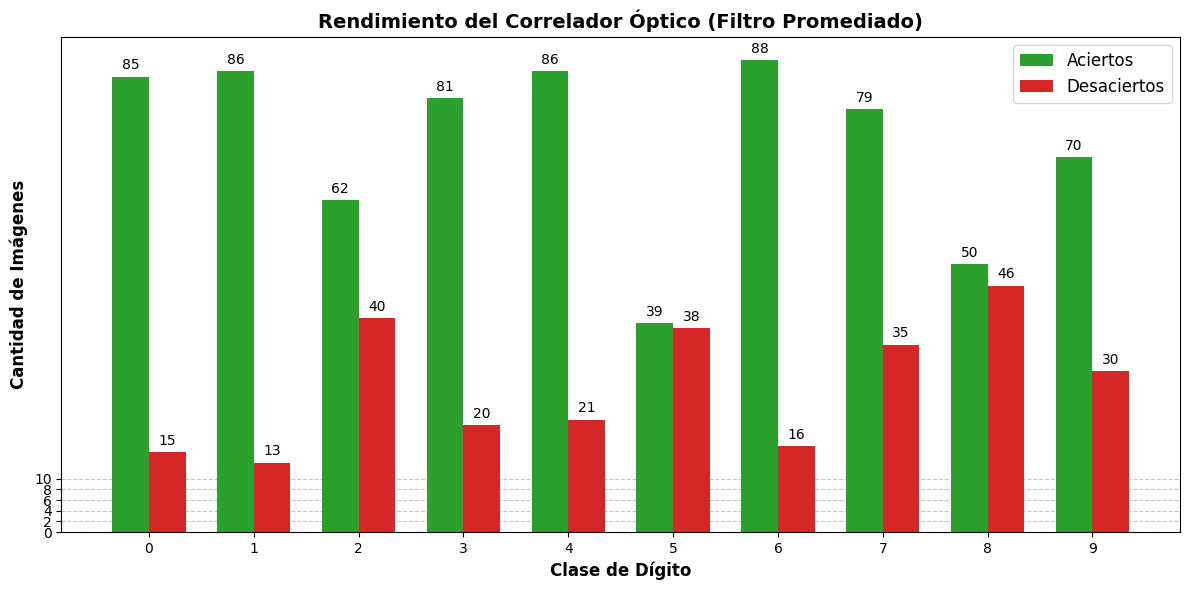

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import psutil
import os
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from codecarbon import EmissionsTracker

# Set up process monitor for RAM usage
process = psutil.Process(os.getpid())

# ==========================================
# 0. FUNCIONES SINCRONIZADAS DEL CORRELADOR
# ==========================================
def create_circular_mask(h, w, r_in=2, r_out=45, mask_type='bandpass'):
    center = (int(w/2), int(h/2))
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    if mask_type == 'bandpass':
        mask = (dist >= r_in) & (dist <= r_out)
    elif mask_type == 'highpass':
        mask = dist >= r_in
    elif mask_type == 'lowpass':
        mask = dist <= r_out
    else:
        mask = np.ones((h, w))
    return mask.astype(float)

def optical_correlator(input_img, target_img, apply_iris=True, r_in=2, r_out=45, mask_type='bandpass'):
    input_img = np.asarray(input_img, dtype=float)
    target_img = np.asarray(target_img, dtype=float)

    U_in_focal = np.fft.fftshift(np.fft.fft2(input_img))
    target_spectrum = np.fft.fftshift(np.fft.fft2(target_img))
    H_filter = np.conj(target_spectrum)

    if apply_iris:
        h, w = U_in_focal.shape
        iris_mask = create_circular_mask(h, w, r_in=r_in, r_out=r_out, mask_type=mask_type)
        H_filter = H_filter * iris_mask

    U_filtered = U_in_focal * H_filter
    U_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))
    return np.abs(U_out)**2

# ==========================================
# 1. GENERACIÓN DE FILTROS SINTÉTICOS (PROMEDIO) - "TRAINING"
# ==========================================
reference_images = {}
NUM_PROMEDIO = 50
print(f"Generando filtros promediados (N={NUM_PROMEDIO}) para mejorar robustez...")

# --- START TRAINING PROFILING ---
tracker_train = EmissionsTracker(project_name="Optical_Training", measure_power_secs=1)
tracker_train.start()
start_time_train = time.perf_counter()
mem_before_train = process.memory_info().rss / (1024 * 1024) # in MB

for i in range(10):
    idxs = np.where(labels == str(i))[0][:NUM_PROMEDIO]
    avg_template = np.mean([pad_image(images[idx]) for idx in idxs], axis=0)
    total_energy = np.sqrt(np.sum(avg_template**2))
    reference_images[i] = avg_template / (total_energy + 1e-12)

# --- STOP TRAINING PROFILING ---
mem_after_train = process.memory_info().rss / (1024 * 1024)
end_time_train = time.perf_counter()
emissions_train = tracker_train.stop()

train_time = end_time_train - start_time_train
train_ram = mem_after_train - mem_before_train
train_energy_kwh = tracker_train.final_emissions_data.energy_consumed

# ==========================================
# 2. CARGA DE DATOS ESTRUCTURADOS
# ==========================================
print("Cargando índices de prueba estructurados...")
try:
    indices_prueba = np.load('indices_muestra_1000.npy')
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró 'indices_muestra_1000.npy'.")

y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes...")

# ==========================================
# 3. BUCLE DE CLASIFICACIÓN ÓPTICA - "EVALUATION"
# ==========================================

# --- START EVALUATION PROFILING ---
tracker_eval = EmissionsTracker(project_name="Optical_Evaluation", measure_power_secs=1)
tracker_eval.start()
start_time_eval = time.perf_counter()
mem_before_eval = process.memory_info().rss / (1024 * 1024)

for count, idx in enumerate(indices_prueba):
    test_img = pad_image(images[idx])
    true_label = int(labels[idx])

    test_energy = np.sqrt(np.sum(test_img**2))
    if test_energy > 0:
        test_img = test_img / test_energy

    peak_intensities = np.zeros(10)

    for i in range(10):
        I_out = optical_correlator(
            test_img,
            reference_images[i],
            apply_iris=True,
            r_in=2,
            r_out=3 5,
            mask_type='highpass'
        )
        peak_intensities[i] = np.max(I_out)

    predicted_digit = np.argmax(peak_intensities)
    y_true.append(true_label)
    y_pred.append(predicted_digit)

# --- STOP EVALUATION PROFILING ---
mem_after_eval = process.memory_info().rss / (1024 * 1024)
end_time_eval = time.perf_counter()
emissions_eval = tracker_eval.stop()

eval_time = end_time_eval - start_time_eval
eval_ram = mem_after_eval - mem_before_eval
eval_energy_kwh = tracker_eval.final_emissions_data.energy_consumed

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ==========================================
# 4. REPORTE DE RECURSOS Y RENDIMIENTO
# ==========================================
print("\n" + "="*45)
print("   PERFIL DE RECURSOS (RESOURCE PROFILING)")
print("="*45)
print("FASE DE ENTRENAMIENTO (Generación de filtros):")
print(f"  - Tiempo de ejecución : {train_time:.4f} segundos")
print(f"  - Consumo de RAM (Est): {train_ram:.2f} MB")
print(f"  - Energía consumida   : {train_energy_kwh:.6f} kWh")

print("\nFASE DE EVALUACIÓN (Correlación):")
print(f"  - Tiempo de ejecución : {eval_time:.4f} segundos")
print(f"  - Consumo de RAM (Est): {eval_ram:.2f} MB")
print(f"  - Energía consumida   : {eval_energy_kwh:.6f} kWh")

print("\n" + "="*45)
print("   MÉTRICAS DE CLASIFICACIÓN (FILTRO PROMEDIADO)")
print("="*45)
print(f"Precisión global (Accuracy): {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred))

# ==========================================
# 5. GENERACIÓN DE GRÁFICA DE RENDIMIENTO
# ==========================================
aciertos = np.zeros(10)
desaciertos = np.zeros(10)

for i in range(10):
    mask = (y_true == i)
    aciertos[i] = np.sum(y_pred[mask] == i)
    desaciertos[i] = np.sum(y_pred[mask] != i)

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, aciertos, width, label='Aciertos', color='#2ca02c')
rects2 = ax.bar(x + width/2, desaciertos, width, label='Desaciertos', color='#d62728')

ax.set_xlabel('Clase de Dígito', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Imágenes', fontsize=12, fontweight='bold')
ax.set_title('Rendimiento del Correlador Óptico (Filtro Promediado)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_yticks(np.arange(0, 12, 2))
ax.legend(fontsize=12)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()